# Computational Trade-offs (Overheads)

**Research questions addressed:**
> RQ4: What are the computational and operational trade-offs of using eBPF-enhanced detection?

This notebook is the **only canonical overhead benchmark** in the repository.

**Canonical protocol**
- Inputs: the saved Split 4 realistic headline artifacts from Notebook 01
- Dataset slice: Split 4 realistic test set
- Benchmark mode: load the saved artifact, align features, run one warmup scoring pass, then time repeated scoring on a fixed first-`N` row sample
- Reported units: seconds for load/latency, `ms per 1k rows` for normalized scoring speed, bytes/MB for artifact size

Notebook 03 must only reference these outputs; it should not run an independent timing method.


In [4]:
import os, sys, json, subprocess
from pathlib import Path

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import GENERALIZATION_SPLITS_BASELINE, GENERALIZATION_SPLITS_EBPF, MODELS_DIR, RANDOM_SEED

BASELINE_SPLITS = Path(GENERALIZATION_SPLITS_BASELINE)
EBPF_SPLITS     = Path(GENERALIZATION_SPLITS_EBPF)
BASELINE_MODEL  = Path(MODELS_DIR) / f'baseline_headline_model_seed{RANDOM_SEED}.joblib'
EBPF_MODEL      = Path(MODELS_DIR) / f'ebpf_headline_model_seed{RANDOM_SEED}.joblib'

OUT_JSON = Path('data/reports/overheads/overheads.json')
OUT_DIR  = Path('data/reports/overheads/artifacts')

OUT_JSON.parent.mkdir(parents=True, exist_ok=True)


In [ ]:
cmd = [
    'python3', 'ml/benchmarks/overheads.py',
    '--baseline_splits_dir', str(BASELINE_SPLITS),
    '--ebpf_splits_dir', str(EBPF_SPLITS),
    '--baseline_model_pack', str(BASELINE_MODEL),
    '--ebpf_model_pack', str(EBPF_MODEL),
    '--test_file', 'test_realistic',
    '--skip_training',
    '--infer_sample_n', '10000',
    '--infer_repeats', '7',
    '--out_json', str(OUT_JSON),
    '--out_dir', str(OUT_DIR),
]

print(' '.join(cmd))
subprocess.run(cmd, check=True)

data = json.loads(OUT_JSON.read_text())
print(json.dumps(data.get('benchmark_protocol', {}), indent=2))
data


python3 ml/benchmarks/overheads.py --baseline_splits_dir /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed42 --ebpf_splits_dir /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed42 --baseline_model_pack /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_headline_model_seed42.joblib --ebpf_model_pack /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/ebpf_headline_model_seed42.joblib --test_file test_realistic --skip_training --infer_sample_n 10000 --infer_repeats 7 --out_json data/reports/overheads/overheads.json --out_dir data/reports/overheads/artifacts
[OK] Wrote data/reports/overheads/overheads.json
{
  "train_load_measurement": "wall_clock_seconds_to_read_train_parquet",
  "test_load_measurement": "wall_clock_seconds_to_read_requested_test_parquet",
  "inference_measurement": "saved-artifact scoring latency on a fixed first-N-row sample after one warmu

{'system': {'timestamp_utc': '2026-03-03T13:10:47Z',
  'python': '3.10.12',
  'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2+-x86_64-with-glibc2.35',
  'machine': 'x86_64',
  'cpu_count': 16},
 'inputs': {'baseline_splits_dir': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed42',
  'ebpf_splits_dir': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed42',
  'baseline_model_pack': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/baseline_headline_model_seed42.joblib',
  'ebpf_model_pack': '/mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models/ebpf_headline_model_seed42.joblib',
  'test_file': 'test_realistic',
  'label_col': 'is_attack',
  'skip_training': True},
 'load_times_seconds': {'baseline_train': 1.7834485310013406,
  'baseline_test': 0.8033847869955935,
  'ebpf_train': 1.8318021110026166,
  'ebpf_test': 0.7458899600023869},
 'dataset_shapes': {'basel

## Visual summary of canonical overhead results

These figures visualize the single canonical benchmark artifact. They do **not** mix full-test timing with sampled timing: every latency chart below comes from the saved-artifact fixed-sample protocol described above.


[+] Saved overhead summary table: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads_summary_seed42.csv


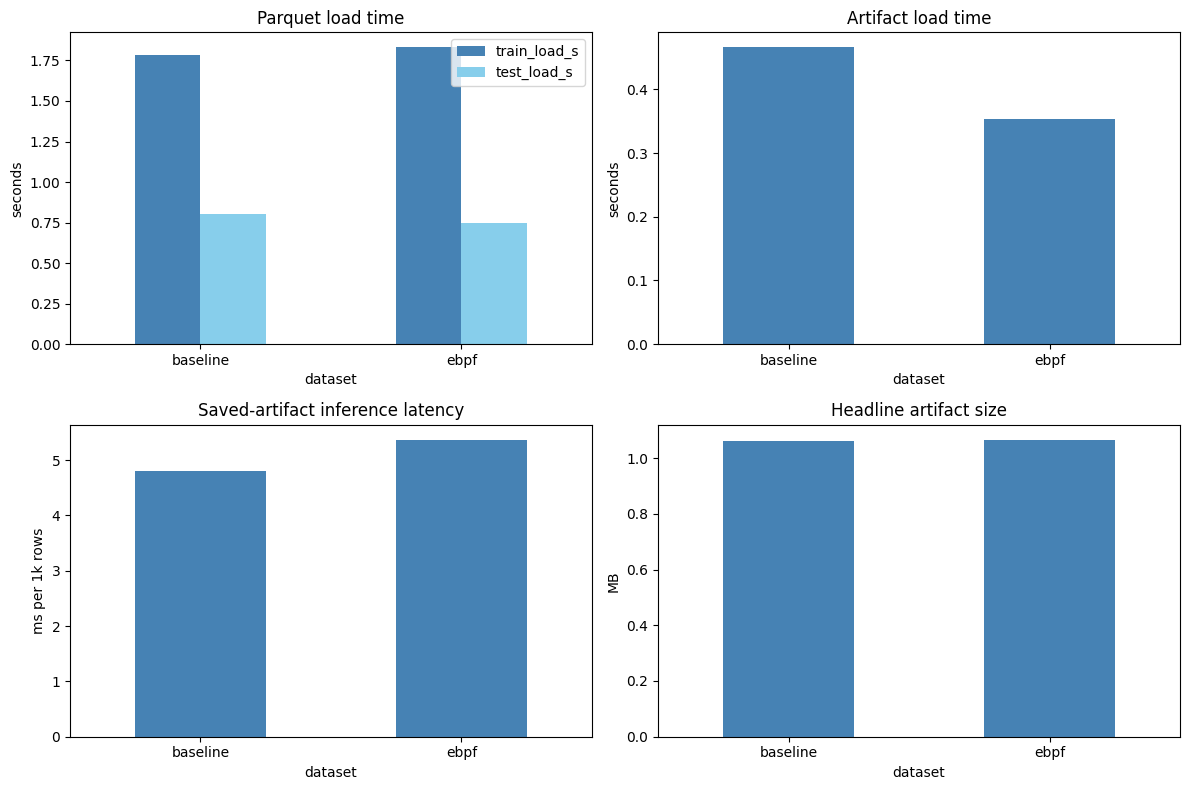

[+] Saved overhead figure: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads/overheads_summary_seed42.png


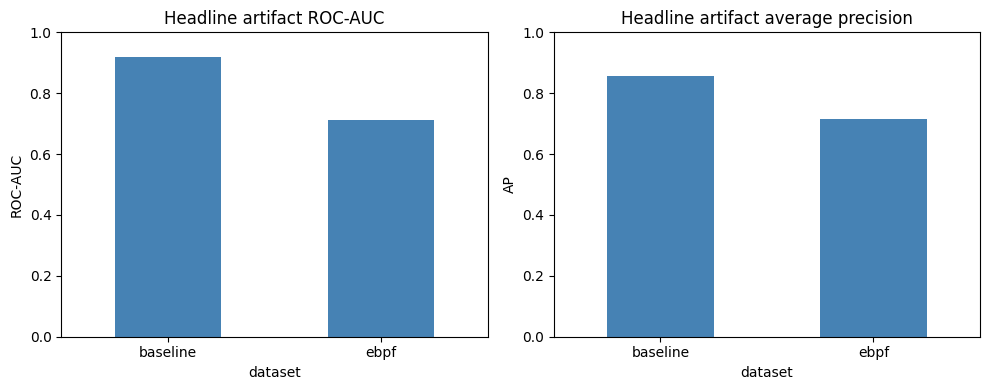

[+] Saved overhead quality figure: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/overheads/overheads_quality_seed42.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

models_df = pd.DataFrame(data['models'])
models_df

summary_df = models_df.copy()
summary_df['model_size_mb'] = summary_df['model_size_bytes'] / (1024 ** 2)
summary_cols = [
    'dataset', 'model', 'artifact_load_seconds', 'latency_mean_seconds',
    'latency_std_seconds', 'infer_ms_per_1k', 'infer_rows_benchmarked',
    'latency_repeats', 'model_size_mb', 'test_auc', 'test_ap',
]
summary_cols = [c for c in summary_cols if c in summary_df.columns]
summary_out = REPO_ROOT / 'data' / 'reports' / f'overheads_summary_seed{RANDOM_SEED}.csv'
summary_df[summary_cols].to_csv(summary_out, index=False)
print(f'[+] Saved overhead summary table: {summary_out}')

load_df = pd.DataFrame({
    'dataset': ['baseline', 'ebpf'],
    'train_load_s': [data['load_times_seconds']['baseline_train'], data['load_times_seconds']['ebpf_train']],
    'test_load_s': [data['load_times_seconds']['baseline_test'], data['load_times_seconds']['ebpf_test']],
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

load_df.set_index('dataset')[['train_load_s', 'test_load_s']].plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'skyblue'])
axes[0, 0].set_title('Parquet load time')
axes[0, 0].set_ylabel('seconds')
axes[0, 0].tick_params(axis='x', rotation=0)

models_df.set_index('dataset')[['artifact_load_seconds']].plot(kind='bar', ax=axes[0, 1], legend=False, color=['steelblue', 'darkorange'])
axes[0, 1].set_title('Artifact load time')
axes[0, 1].set_ylabel('seconds')
axes[0, 1].tick_params(axis='x', rotation=0)

models_df.set_index('dataset')[['infer_ms_per_1k']].plot(kind='bar', ax=axes[1, 0], legend=False, color=['steelblue', 'darkorange'])
axes[1, 0].set_title('Saved-artifact inference latency')
axes[1, 0].set_ylabel('ms per 1k rows')
axes[1, 0].tick_params(axis='x', rotation=0)

summary_df.set_index('dataset')[['model_size_mb']].plot(kind='bar', ax=axes[1, 1], legend=False, color=['steelblue', 'darkorange'])
axes[1, 1].set_title('Headline artifact size')
axes[1, 1].set_ylabel('MB')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
summary_png = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'overheads_summary_seed{RANDOM_SEED}.png'
plt.savefig(summary_png, dpi=150)
plt.show()
print(f'[+] Saved overhead figure: {summary_png}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
quality_df = models_df.set_index('dataset')[['test_auc', 'test_ap']]
quality_df[['test_auc']].plot(kind='bar', ax=axes[0], legend=False, color=['steelblue', 'darkorange'])
axes[0].set_title('Headline artifact ROC-AUC')
axes[0].set_ylabel('ROC-AUC')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 1.0)

quality_df[['test_ap']].plot(kind='bar', ax=axes[1], legend=False, color=['steelblue', 'darkorange'])
axes[1].set_title('Headline artifact average precision')
axes[1].set_ylabel('AP')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
quality_png = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'overheads_quality_seed{RANDOM_SEED}.png'
plt.savefig(quality_png, dpi=150)
plt.show()
print(f'[+] Saved overhead quality figure: {quality_png}')

if data.get('netmon_overhead'):
    netmon_csv = Path(data['netmon_overhead']['csv'])
    if netmon_csv.exists():
        netmon_df = pd.read_csv(netmon_csv)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(netmon_df['ts'], netmon_df['cpu_percent'], color='darkorange')
        axes[0].set_title('netmon CPU over time')
        axes[0].set_ylabel('CPU %')
        axes[0].set_xlabel('timestamp')

        axes[1].plot(netmon_df['ts'], netmon_df['rss_bytes'] / (1024 ** 2), color='steelblue')
        axes[1].set_title('netmon RSS over time')
        axes[1].set_ylabel('MB')
        axes[1].set_xlabel('timestamp')

        plt.tight_layout()
        plt.show()


## Live `netmon` overhead protocol

The live collector measurement below is fully standalone. Unlike the offline ML benchmark above, it does **not** need any split parquet files or saved model artifacts from the other notebooks.

**Minimal protocol**
1. Start the workload you want to measure and keep it identical across runs.
2. Ensure `netmon` is already running.
3. Find the current PID, for example with `pgrep -n netmon`.
4. Set `LIVE_SAMPLE_PID` in the next cell.
5. Run the next two cells while the workload is active.
6. Repeat this on at least `3` comparable runs and report mean/std CPU and RSS.

**Important**
- This section measures only the live collector process overhead.
- It should be reported separately from the saved-artifact ML inference benchmark above.
- Keep the workload window, duration, and hardware fixed across runs.


In [16]:
import time
import platform
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psutil
except Exception as exc:
    psutil = None
    print(f'[!] psutil is required for live netmon sampling: {exc}')

LIVE_SAMPLE_PID = 89837          # Replace with the running netmon PID, e.g. 12345
LIVE_SAMPLE_DURATION_S = 60  # Keep fixed across repeated runs
LIVE_SAMPLE_INTERVAL_S = 1.0
# LIVE_TAG = 'netmon_live_run1'
# LIVE_TAG = 'netmon_live_run2'
LIVE_TAG = 'netmon_live_run3'


LIVE_OUT_JSON = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_seed{RANDOM_SEED}.json'
LIVE_OUT_CSV = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_samples_seed{RANDOM_SEED}.csv'

print(f'LIVE_SAMPLE_PID={LIVE_SAMPLE_PID}')
print(f'LIVE_OUT_JSON={LIVE_OUT_JSON}')
print(f'LIVE_OUT_CSV={LIVE_OUT_CSV}')

if LIVE_SAMPLE_PID == 0:
    print('[!] Set LIVE_SAMPLE_PID to the running netmon PID before executing the live-overhead command cell.')


LIVE_SAMPLE_PID=89837
LIVE_OUT_JSON=/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_seed42.json
LIVE_OUT_CSV=/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_samples_seed42.csv


In [17]:
live_data = None

if LIVE_SAMPLE_PID and psutil is not None:
    proc = psutil.Process(LIVE_SAMPLE_PID)
    rows = []
    t_end = time.time() + LIVE_SAMPLE_DURATION_S

    proc.cpu_percent(interval=None)
    while time.time() < t_end:
        ts = time.time()
        cpu = proc.cpu_percent(interval=None)
        mem = proc.memory_info().rss
        rows.append({'ts': ts, 'cpu_percent': cpu, 'rss_bytes': mem})
        time.sleep(LIVE_SAMPLE_INTERVAL_S)

    live_df = pd.DataFrame(rows)
    LIVE_OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    live_df.to_csv(LIVE_OUT_CSV, index=False)

    live_summary = {
        'pid': LIVE_SAMPLE_PID,
        'samples': int(len(live_df)),
        'cpu_percent_mean': float(live_df['cpu_percent'].mean()) if len(live_df) else float('nan'),
        'cpu_percent_p95': float(live_df['cpu_percent'].quantile(0.95)) if len(live_df) else float('nan'),
        'rss_mb_mean': float(live_df['rss_bytes'].mean() / (1024 ** 2)) if len(live_df) else float('nan'),
        'rss_mb_p95': float(live_df['rss_bytes'].quantile(0.95) / (1024 ** 2)) if len(live_df) else float('nan'),
        'csv': str(LIVE_OUT_CSV),
        'duration_s': LIVE_SAMPLE_DURATION_S,
        'interval_s': LIVE_SAMPLE_INTERVAL_S,
        'timestamp_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
        'platform': platform.platform(),
    }

    live_data = {
        'mode': 'standalone_live_netmon_sampling',
        'netmon_overhead': live_summary,
    }
    LIVE_OUT_JSON.write_text(json.dumps(live_data, indent=2))
    print(json.dumps(live_summary, indent=2))
else:
    print('[!] Skipping live `netmon` overhead run because LIVE_SAMPLE_PID is 0 or psutil is unavailable.')


{
  "pid": 89837,
  "samples": 60,
  "cpu_percent_mean": 0.13333333333333333,
  "cpu_percent_p95": 1.0,
  "rss_mb_mean": 49.94798177083333,
  "rss_mb_p95": 49.953125,
  "csv": "/home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_samples_seed42.csv",
  "duration_s": 60,
  "interval_s": 1.0,
  "timestamp_utc": "2026-03-04T12:17:45Z",
  "platform": "Linux-5.15.0-139-generic-x86_64-with-glibc2.29"
}


## Visual summary of live `netmon` overhead

If you ran the previous cell with a real PID, this section loads the saved live-overhead artifacts and produces a small summary table plus CPU/RSS plots for that run.


  pid  samples  cpu_percent_mean  cpu_percent_p95  rss_mb_mean  rss_mb_p95  duration_s  interval_s
89837       60            0.1333           1.0000      49.9480     49.9531          60      1.0000
[+] Saved live-overhead summary table: /home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_summary_seed42.csv


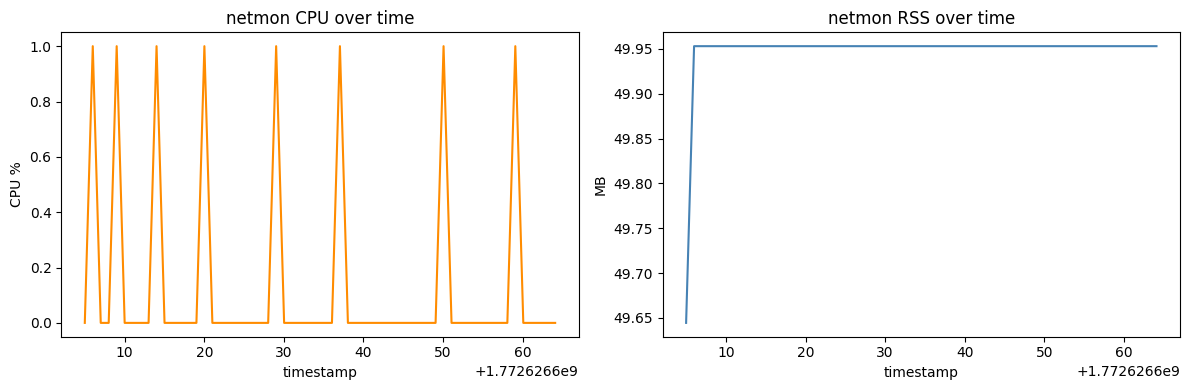

[+] Saved live-overhead plot: /home/merin/projects/ebpf-net-sentinel/data/reports/overheads/netmon_live_run3_plots_seed42.png


In [18]:
live_summary = None
if LIVE_OUT_JSON.exists():
    live_data = json.loads(LIVE_OUT_JSON.read_text())
    live_summary = live_data.get('netmon_overhead')

if live_summary:
    live_df = pd.read_csv(live_summary['csv'])
    live_table = pd.DataFrame([{
        'pid': live_summary['pid'],
        'samples': live_summary['samples'],
        'cpu_percent_mean': live_summary['cpu_percent_mean'],
        'cpu_percent_p95': live_summary['cpu_percent_p95'],
        'rss_mb_mean': live_summary['rss_mb_mean'],
        'rss_mb_p95': live_summary['rss_mb_p95'],
        'duration_s': live_summary.get('duration_s', LIVE_SAMPLE_DURATION_S),
        'interval_s': live_summary.get('interval_s', LIVE_SAMPLE_INTERVAL_S),
    }])
    live_summary_out = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_summary_seed{RANDOM_SEED}.csv'
    live_table.to_csv(live_summary_out, index=False)
    print(live_table.to_string(index=False, float_format='{:.4f}'.format))
    print(f'[+] Saved live-overhead summary table: {live_summary_out}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(live_df['ts'], live_df['cpu_percent'], color='darkorange')
    axes[0].set_title('netmon CPU over time')
    axes[0].set_ylabel('CPU %')
    axes[0].set_xlabel('timestamp')

    axes[1].plot(live_df['ts'], live_df['rss_bytes'] / (1024 ** 2), color='steelblue')
    axes[1].set_title('netmon RSS over time')
    axes[1].set_ylabel('MB')
    axes[1].set_xlabel('timestamp')

    plt.tight_layout()
    live_plot_out = REPO_ROOT / 'data' / 'reports' / 'overheads' / f'{LIVE_TAG}_plots_seed{RANDOM_SEED}.png'
    plt.savefig(live_plot_out, dpi=150)
    plt.show()
    print(f'[+] Saved live-overhead plot: {live_plot_out}')
else:
    print(f'[!] Live-overhead JSON not found or contains no netmon sample: {LIVE_OUT_JSON}')
